# 02 - Exploratory Data Analysis (EDA)

In this notebook, we analyze the flight booking dataset to understand patterns and relationships between features.

The main goal is to extract insights that influence flight ticket prices.
We focus on visualizing key variables and understanding their impact on the target price variable.

In [5]:
# basic libraries
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# set the style of the plots
sns.set(style="whitegrid")

In [6]:
# get the cleaned data
df = pd.read_csv("../data/cleaned/flight_data.csv")

# check the first few rows of the data
print(df.head())

    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
2   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
3   Vistara   UK-963       Delhi        Morning  zero        Morning   
4   Vistara   UK-945       Delhi        Morning  zero      Afternoon   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.17          1   5956  
2           Mumbai  Economy      2.25          1   5955  
3           Mumbai  Economy      2.33          1   5955  
4           Mumbai  Economy      2.33          1   5955  


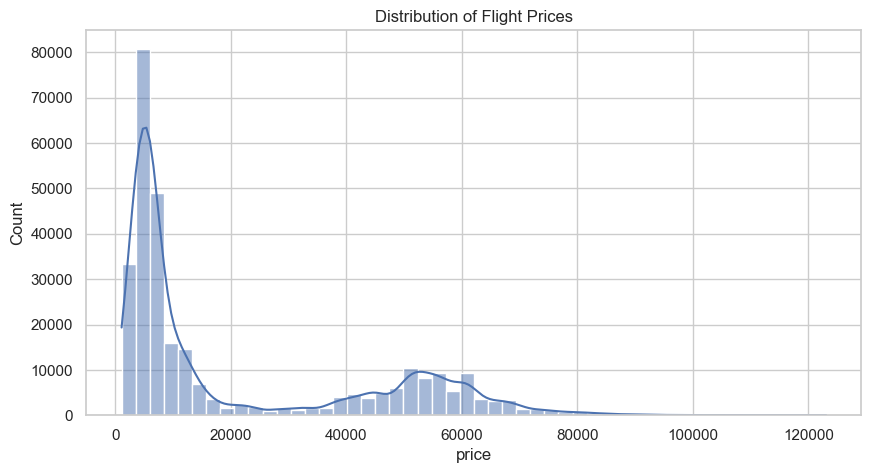

In [7]:
# plot the distribution of flight prices
plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Flight Prices")
plt.show()

Most flight prices are concentrated in a lower range, with fewer expensive tickets.
This indicates a right-skewed distribution.

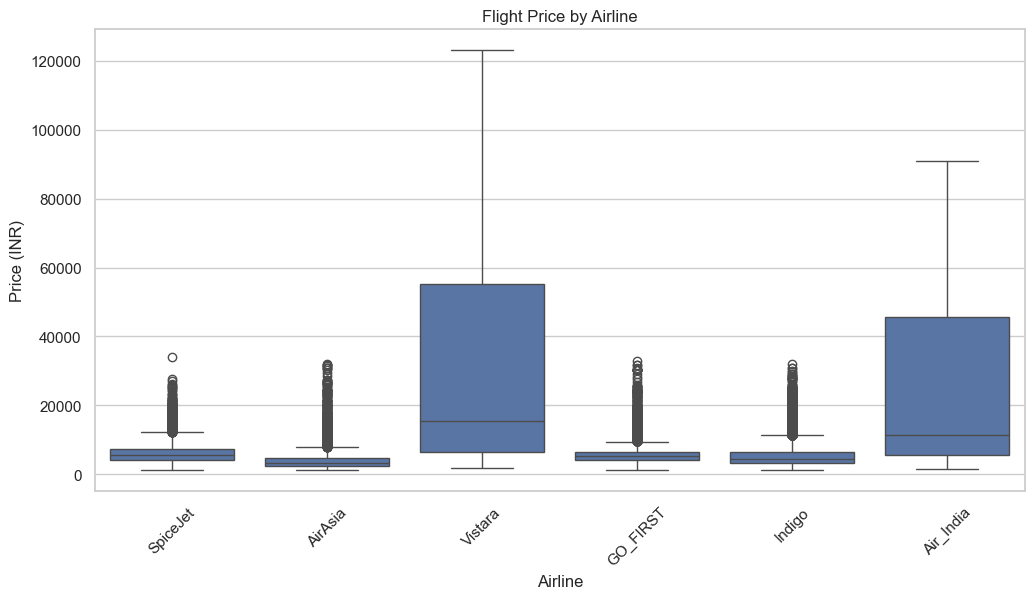

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(x="airline", y="price", data=df)

plt.title("Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)

plt.show()

This plot shows how flight prices vary across different airlines.

We can observe that some airlines tend to have higher or lower price ranges compared to others.

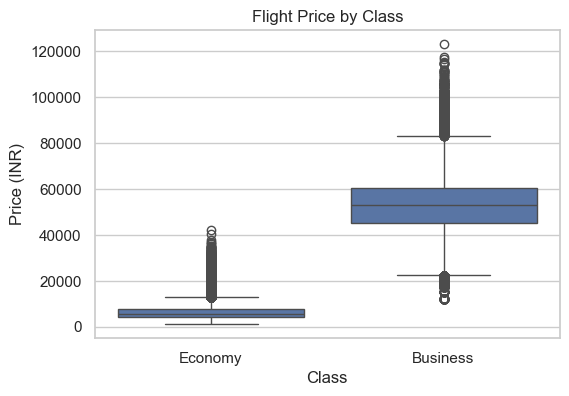

In [13]:
plt.figure(figsize=(6,4))

sns.boxplot(x="class", y="price", data=df)

plt.title("Flight Price by Class")
plt.xlabel("Class")
plt.ylabel("Price (INR)")

plt.show()

Business class tickets are significantly more expensive than economy class tickets.

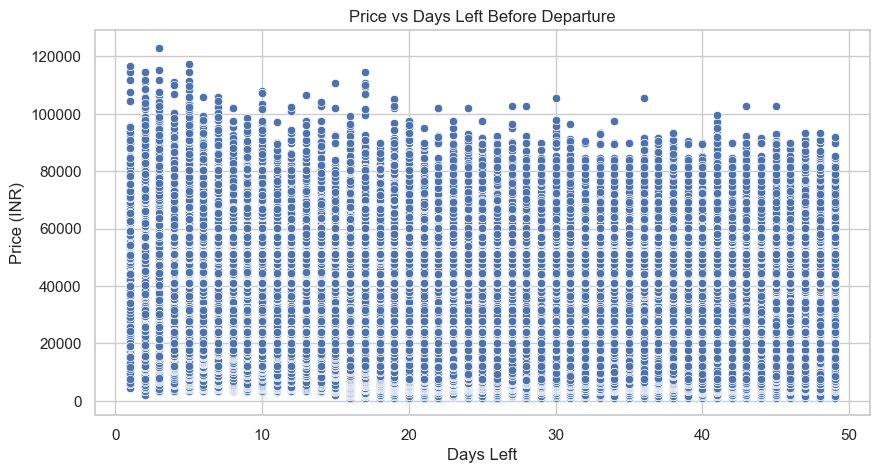

In [14]:
plt.figure(figsize=(10,5))

sns.scatterplot(x="days_left", y="price", data=df)

plt.title("Price vs Days Left Before Departure")
plt.xlabel("Days Left")
plt.ylabel("Price (INR)")

plt.show()

Prices tend to decrease a bit when booking earlier.

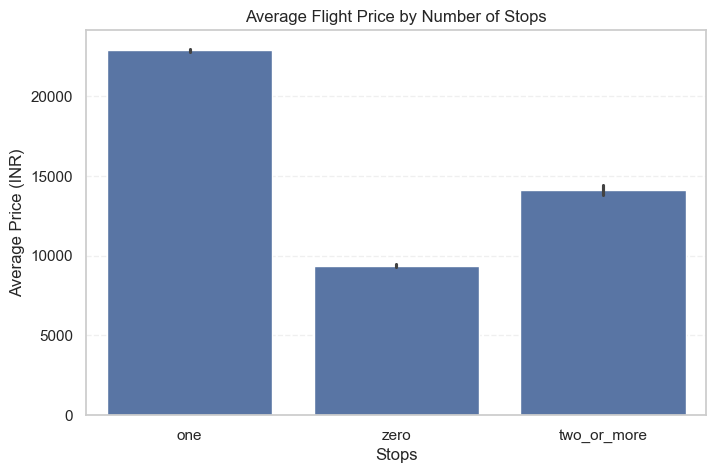

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="stops",
    y="price",
    data=df,
    order=df["stops"].value_counts().index
)

plt.title("Average Flight Price by Number of Stops")
plt.xlabel("Stops")
plt.ylabel("Average Price (INR)")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

We observe that flights with 1 stop tend to have higher average prices.
Flights with zero stops are generally cheaper, which is expected for direct flights.

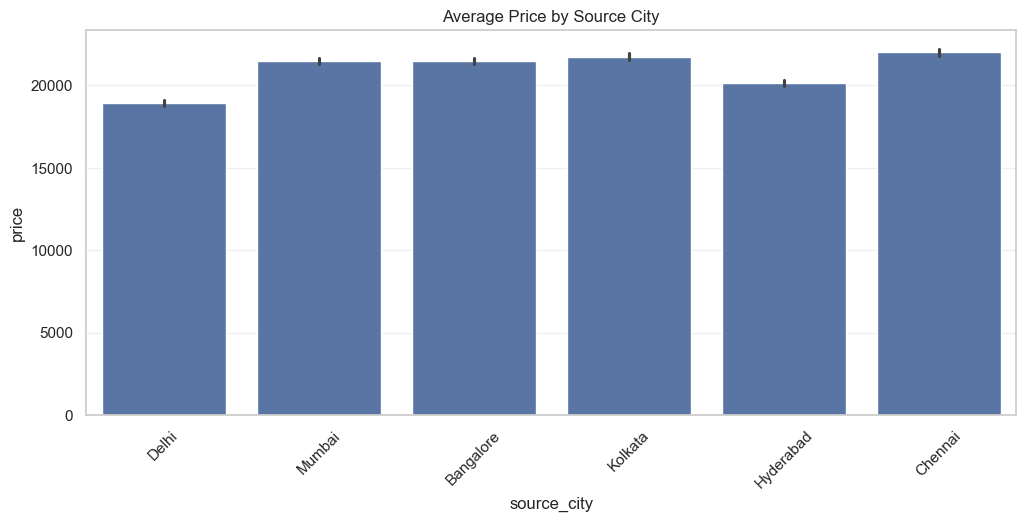

In [18]:
plt.figure(figsize=(12,5))

sns.barplot(x="source_city", y="price", data=df, estimator=np.mean)

plt.xticks(rotation=45)
plt.title("Average Price by Source City")
plt.grid(axis="y", alpha=0.3)

plt.show()

Source city does not impact a lot the price ticket.

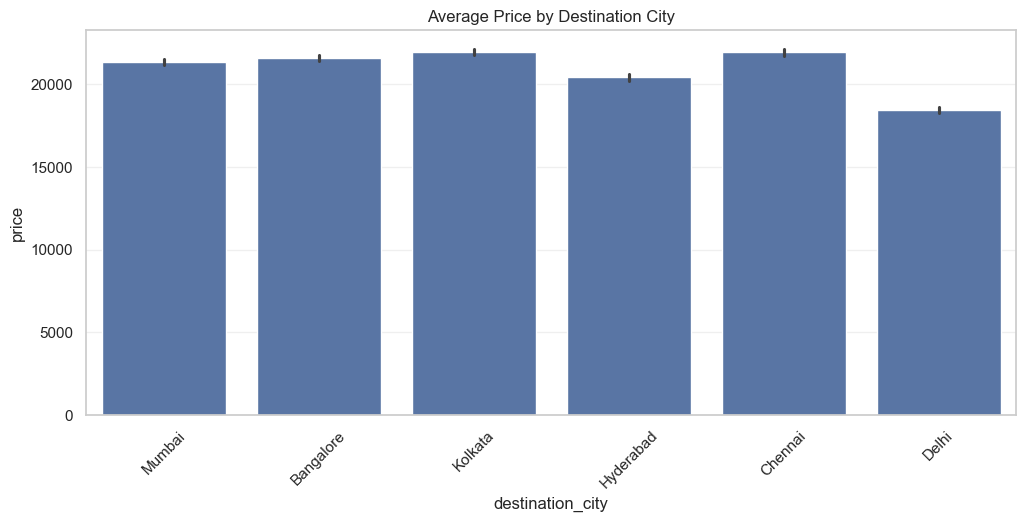

In [20]:
plt.figure(figsize=(12,5))

sns.barplot(x="destination_city", y="price", data=df, estimator=np.mean)

plt.xticks(rotation=45)
plt.title("Average Price by Destination City")
plt.grid(axis="y", alpha=0.3)

plt.show()

Destination city does also not impact a lot the price ticket.

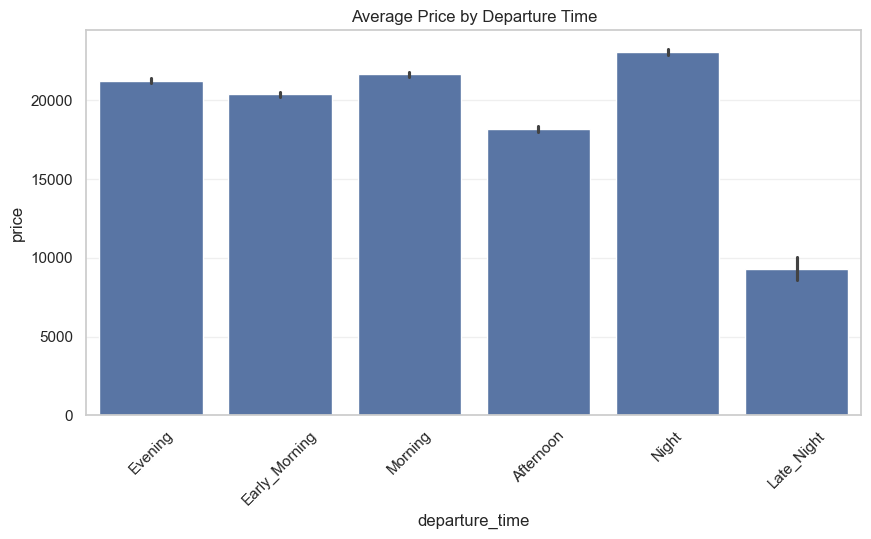

In [21]:
plt.figure(figsize=(10,5))

sns.barplot(x="departure_time", y="price", data=df, estimator=np.mean)

plt.xticks(rotation=45)
plt.title("Average Price by Departure Time")
plt.grid(axis="y", alpha=0.3)

plt.show()

Late night departure flights tends to be a lot cheaper than all other times.

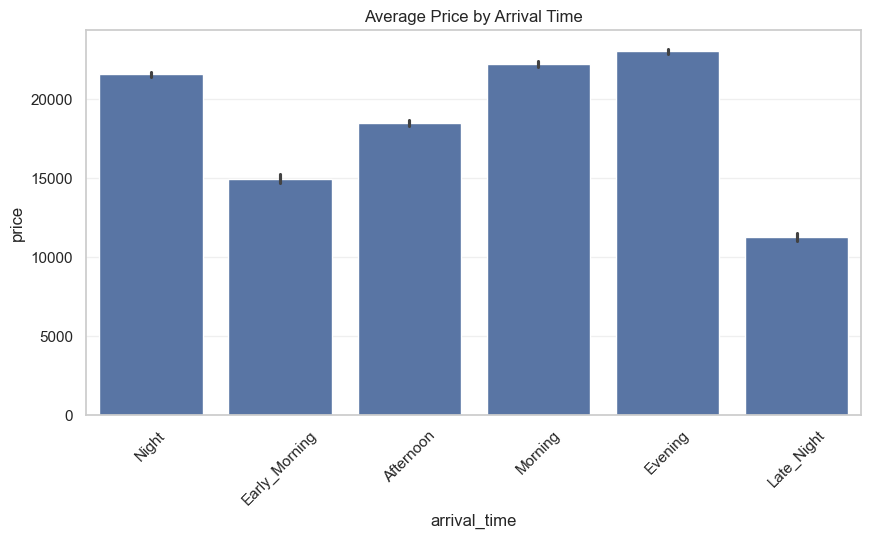

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(x="arrival_time", y="price", data=df, estimator=np.mean)

plt.xticks(rotation=45)
plt.title("Average Price by Arrival Time")
plt.grid(axis="y", alpha=0.3)

plt.show()

Early morning arrivals and late night arrivals flights tend to be a lot cheaper.

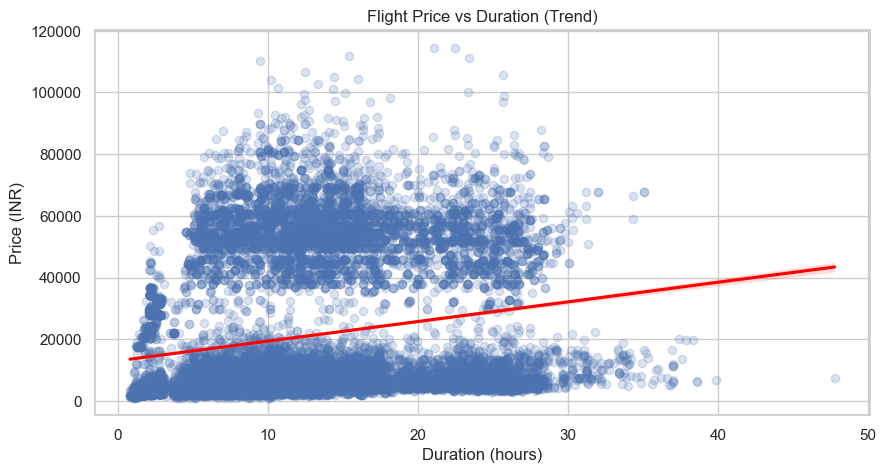

In [27]:
plt.figure(figsize=(10,5))

sample_df = df.sample(20000, random_state=42)

sns.regplot(
    x="duration",
    y="price",
    data=sample_df,
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title("Flight Price vs Duration (Trend)")
plt.xlabel("Duration (hours)")
plt.ylabel("Price (INR)")

plt.show()

Longer flights do cost more.

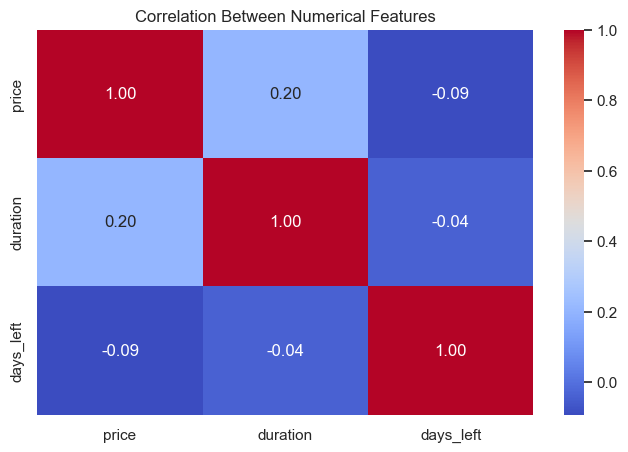

In [23]:
plt.figure(figsize=(8,5))

corr = df[["price", "duration", "days_left"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Numerical Features")
plt.show()

The heatmap shows that flight duration is indeed positively correlated with ticket price, meaning that longer flights generally tend to be more expensive.

We can also observe a slight negative correlation between the number of days left before departure and the ticket price.

## Conclusion

Based on the different visualizations and analyses, we can suppose that several factors influence flight ticket prices.

The airline company and the travel class seem to have a strong impact on prices, with Business class tickets generally being much more expensive than Economy class tickets. Flight duration also appears positively related to ticket price.

Flights with 1 stop tend to be significantly more expensive, while non-stop flights are generally the cheapest.

The analysis also suggests that booking earlier may help reduce ticket prices, while departure and arrival times can slightly affect fares, especially for late-night or early-morning flights.

In contrast, source and destination cities do not appear to create major differences in prices overall.

These observations provide useful insights and will help guide the machine learning models developed in the next steps of the project.